In [3]:
import os

def remove_unsupported_images(root_dir):
    allowed_exts = [".jpg", ".jpeg", ".png", ".bmp", ".gif"]
    for subdir, _, files in os.walk(root_dir):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext not in allowed_exts:
                file_path = os.path.join(subdir, file)
                print(f"Deleting unsupported file: {file_path}")
                os.remove(file_path)

remove_unsupported_images(r'C:\Users\sujic\Downloads\Plant Model\house_plant_species')

In [5]:
import os
import tensorflow as tf
def remove_invalid_images(dataset_path):
    count_removed = 0
    for root, _, files in os.walk(dataset_path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                img = tf.io.read_file(file_path)
                img = tf.image.decode_image(img, channels=3)  # Triggers error if unsupported
                _ = img.shape  # Force evaluation
            except Exception as e:
                print(f"Removing invalid image: {file_path} — {str(e)}")
                os.remove(file_path)
                count_removed += 1
    print(f"Total removed: {count_removed}")
#give your own path
remove_invalid_images(r'C:\Users\sujic\Downloads\Plant Model\house_plant_species')

Removing invalid image: C:\Users\sujic\Downloads\Plant Model\house_plant_species\African Violet (Saintpaulia ionantha)\187.jpg — {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
Removing invalid image: C:\Users\sujic\Downloads\Plant Model\house_plant_species\African Violet (Saintpaulia ionantha)\271.jpg — {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
Removing invalid image: C:\Users\sujic\Downloads\Plant Model\house_plant_species\African Violet (Saintpaulia ionantha)\308.jpg — {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
Removing invalid image: C:\Users\sujic\Downloads\Plant Model\house_pla

In [7]:
import os
import shutil
import random
from pathlib import Path

# Set paths
ORIGINAL_DATASET_DIR = "house_plant_species"
OUTPUT_DIR = "split_plant_dataset"
SPLIT_RATIOS = (0.7, 0.2, 0.1)  # Train, Val, Test

# Ensure output folders exist
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

# Loop through each class folder
for class_name in os.listdir(ORIGINAL_DATASET_DIR):
    class_dir = os.path.join(ORIGINAL_DATASET_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue

    # List images
    images = [img for img in os.listdir(class_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(images)

    # Split indices
    total = len(images)
    train_end = int(total * SPLIT_RATIOS[0])
    val_end = train_end + int(total * SPLIT_RATIOS[1])

    splits = {
        'train': images[:train_end],
        'val': images[train_end:val_end],
        'test': images[val_end:]
    }

    # Copy images
    for split, split_images in splits.items():
        split_dir = os.path.join(OUTPUT_DIR, split, class_name)
        os.makedirs(split_dir, exist_ok=True)

        for image in split_images:
            src_path = os.path.join(class_dir, image)
            dst_path = os.path.join(split_dir, image)
            shutil.copyfile(src_path, dst_path)

print("✅ Dataset successfully split into train, val, and test folders.")


✅ Dataset successfully split into train, val, and test folders.


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input

# Early stopping with longer patience
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Settings
IMAGE_SIZE = 260  # Slightly larger for EfficientNetB2
BATCH_SIZE = 32
EPOCHS = 20
DATA_DIR = "split_plant_dataset"

# Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

# Extract class names BEFORE mapping
class_names = train_ds.class_names
n_classes = len(class_names)


# Prefetch & preprocess
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(image, label):
    return preprocess_input(image), label

train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(buffer_size=AUTOTUNE)



# Data Augmentation (enhanced)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.4),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.4),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
])

# Base model: EfficientNetB2
base_model = EfficientNetB2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # We'll fine-tune later

# Full model
inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(n_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train (initial)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

# ✅ Fine-tune: unfreeze base model
base_model.trainable = True

# Recompile with lower LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train (fine-tuning)
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

# Save model
model.save("improved_plant_classifier_model.keras")

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)
print(f"✅ Test Accuracy: {test_acc:.2%}")

Found 5719 files belonging to 25 classes.
Found 1626 files belonging to 25 classes.
Found 844 files belonging to 25 classes.
Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.0653 - loss: 3.9881 - val_accuracy: 0.2515 - val_loss: 2.6111
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.1972 - loss: 2.9670 - val_accuracy: 0.4422 - val_loss: 1.9866
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.2987 - loss: 2.4792 - val_accuracy: 0.5252 - val_loss: 1.6640
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.3818 - loss: 2.1713 - val_accuracy: 0.5775 - val_loss: 1.4775
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.4288 - loss: 2.0108 - val_accuracy: 0.6113 - val_loss: 1.3418
Epoch 6/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 292s 2s/step - accuracy: 0.4759 - loss: 1.8197 - val_accuracy: 0.6353 - val_loss: 1.2458
Epoch 7/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - accuracy: 0.5073 - loss: 1.7033 - val_accuracy

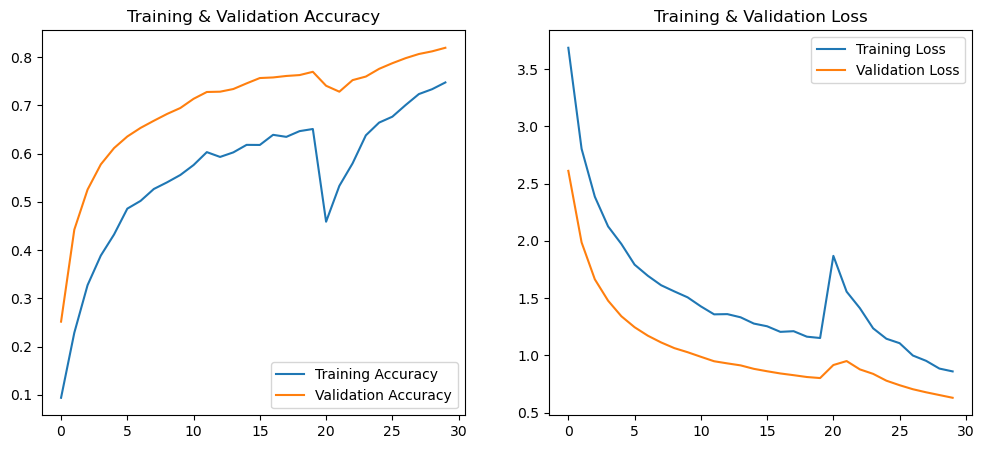

<Figure size 640x480 with 0 Axes>

In [42]:
# 🔥 Plot training history
def plot_history(history, history_fine=None):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    if history_fine:
        acc += history_fine.history['accuracy']
        val_acc += history_fine.history['val_accuracy']
        loss += history_fine.history['loss']
        val_loss += history_fine.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training & Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training & Validation Loss')

    plt.show()

# Plot
plot_history(history, history_fine)
plt.savefig('accuracy_plot.png')
plt.savefig('loss_plot.png')

In [44]:
model.save("improved_plant_classifier_model.keras")

In [47]:
print("Class names:", class_names)

Class names: ['African Violet (Saintpaulia ionantha)', 'Aloe Vera', 'Anthurium (Anthurium andraeanum)', 'Areca Palm (Dypsis lutescens)', 'Begonia (Begonia spp.)', 'Bird of Paradise (Strelitzia reginae)', 'Calathea', 'Christmas Cactus (Schlumbergera bridgesii)', 'Chrysanthemum', 'Daffodils (Narcissus spp.)', 'Dumb Cane (Dieffenbachia spp.)', 'Hyacinth (Hyacinthus orientalis)', 'Jade plant (Crassula ovata)', 'Kalanchoe', 'Lilium (Hemerocallis)', 'Lily of the valley (Convallaria majalis)', 'Monstera Deliciosa (Monstera deliciosa)', 'Orchid', 'Peace lily', 'Poinsettia (Euphorbia pulcherrima)', 'Polka Dot Plant (Hypoestes phyllostachya)', 'Rubber Plant (Ficus elastica)', 'Snake plant (Sanseviera)', 'Tradescantia', 'Tulip']


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


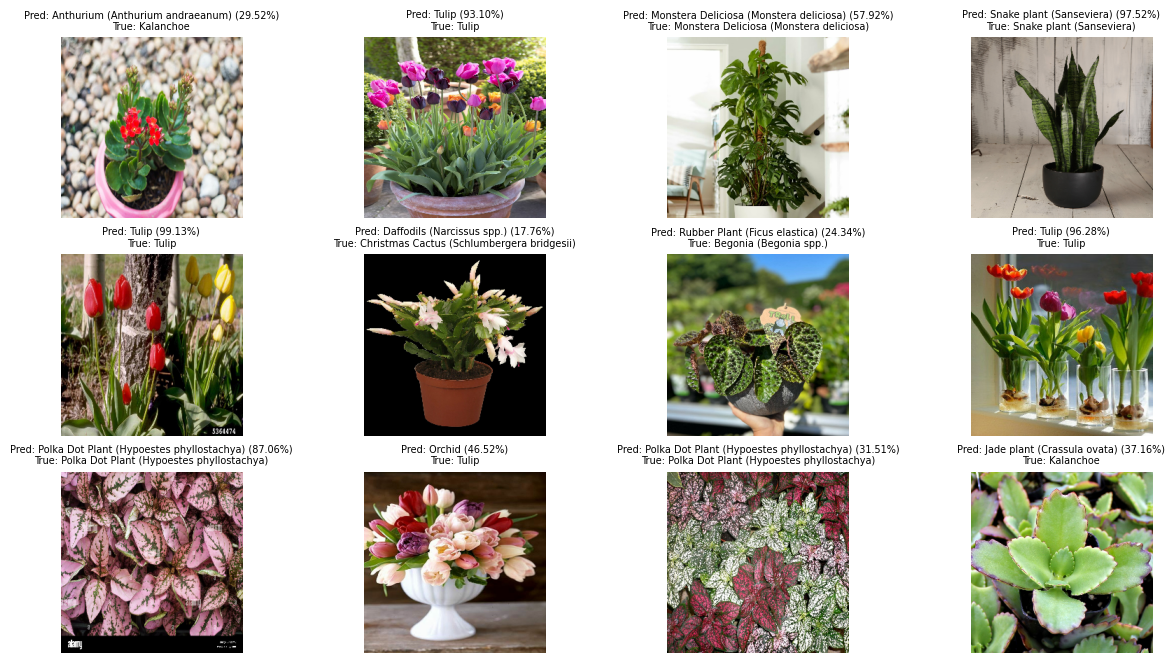

In [49]:
import matplotlib.pyplot as plt
import numpy as np

def show_sample_predictions(model, dataset, class_names, num_images=12):
    plt.figure(figsize=(15, 8))
    i = 0
    for images, labels in dataset.unbatch().take(num_images):
        ax = plt.subplot(3, 4, i + 1)
        img_array = np.expand_dims(images.numpy(), axis=0)
        preds = model.predict(img_array)
        pred_class = class_names[np.argmax(preds)]
        true_class = class_names[labels.numpy()]
        
        confidence = np.max(preds) * 100  # Get the confidence as percentage
        
        # Plot the image
        plt.imshow(images.numpy().astype("uint8"))
        plt.title(f"Pred: {pred_class} ({confidence:.2f}%)\nTrue: {true_class}", fontsize=7)
        plt.axis("off")
        i += 1
    plt.show()

# Usage
show_sample_predictions(model, test_ds, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 55s 55s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 803ms/step


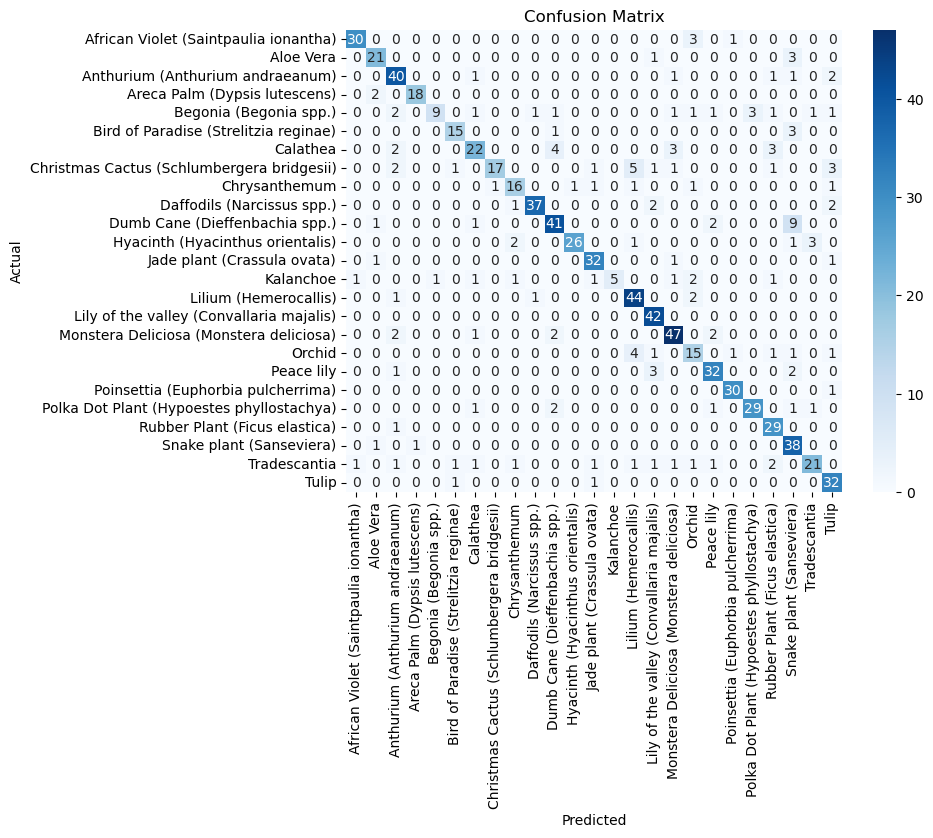

                                            precision    recall  f1-score   support

     African Violet (Saintpaulia ionantha)       0.94      0.88      0.91        34
                                 Aloe Vera       0.81      0.84      0.82        25
          Anthurium (Anthurium andraeanum)       0.77      0.87      0.82        46
             Areca Palm (Dypsis lutescens)       0.95      0.90      0.92        20
                    Begonia (Begonia spp.)       0.90      0.39      0.55        23
     Bird of Paradise (Strelitzia reginae)       0.83      0.79      0.81        19
                                  Calathea       0.76      0.65      0.70        34
Christmas Cactus (Schlumbergera bridgesii)       0.94      0.53      0.68        32
                             Chrysanthemum       0.76      0.73      0.74        22
                Daffodils (Narcissus spp.)       0.95      0.88      0.91        42
            Dumb Cane (Dieffenbachia spp.)       0.80      0.76      0.78  

In [67]:
#Confusion Matrix
#A confusion matrix shows where your model is getting things right vs wrong
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(model, dataset, class_names):
    # Get true and predicted labels
    y_true = []
    y_pred = []
    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()
    
    # Optional: Print classification report
    print(classification_report(y_true, y_pred, target_names=class_names))

# Usage
plot_confusion_matrix(model, test_ds, class_names)
